# VSS 2026 Poster
This notebook contains the code used to generate the figures for our VSS 2026 poster: _"Fixated but Failed to See: Recognition Errors in Visual Search"_ ([poster 3139](https://www.visionsciences.org/presentation/?id=3139)).<br>
We also generate QR codes embedded in the final poster that link to this notebook and to example data available online.

#### Runtime
**Model Fitting**: 2-3 minutes
**Notebool Run** (without fitting a model): 4-6 minutes (depending on calls to `save_figure()` increasing run time)
**Total Runtime: 7-10 minutes**

## Poster Summary
### Background
In visual search tasks, observers often fail to recognize a target even when it is clearly visible. These errors, called **Looked but Failed to See** (LBFTS) errors, have various proposed explanations & causes (Wolfe et al., 2022; Nartker et al., 2023).<br>
Here, we focus on a subset of these errors where participants **fixated on a target yet still did not recognize it**, which we refer to as **Looking without Seeing** (LWS) errors.<br>
Our analysis focuses on target visits (i.e., consecutive fixations on the same target are counted as a single visit) and the probability of an LWS error given a target visit: $P[\text{LWS}] \equiv P[\text{miss} \mid \text{visit}]$.<br>
We examine how low-level and high-level factors, as well as their interactions, influence this probability.

### Statistical Model
We use a hierarchical Bayesian model (HBM) to fit a logistic regression prediction the probability of an LWS error based on the following predictors:
1) Trial Type - categorical variable with levels `color`, `grayscale` and `noise` (color image with noise background).
2) Target Type - categorical variable with levels `animal body`, `animal face`, `human body`, `human face`, `object manmade` and `object natural`.
3) Target Rotation Angle - a continuous variable representing the rotation angle of the target object in the image, in absolute value (we don't care if rotation was counter- or clockwise). For better model convergence, we center this variable by subtracting the mean absolute angle from each value (column `centered_abs_target_angle`).

The model also includes a random intercept for each subject to account for individual differences in overall performance.<br>
The formula for the model is as follows:
$$\text{[miss} \mid \text{on-target]} \sim C(\text{trial\_category}) * C(\text{target\_category}) * \text{centered\_abs\_target\_angle} + (1 \mid \text{subject})$$

### Hypotheses
Our analysis will focus on the following questions:

#### Semantic Contrasts
Semantic category of targets is also known to influence miss rates. For example, animate targets are often detected better than inanimate targets (e.g., Calvillo & Hawkins, 2016); and among animate targets, human faces are often prioritized and detected better than other animate categories (e.g., Simpson et al., 2014; Loucks et al., 2023). Among inanimate targets, detection rates vary by object category, suggesting that some subtypes are inherently more salient (Chen et al., 2021).<br>
However, these findings relate to overall detection rates (i.e., $P[\text{miss} \mid \text{target}]$) rather than the probability of an LWS error given a target visit (i.e., $P[\text{miss} \mid \text{target visit}]$).<br>
Here, we will examine the following semantic contrasts:
1) Animate vs. Inanimate: Is there a difference in LWS probability between animate targets (animals and humans) and inanimate targets (objects)?
2) Human Face vs. Other Animate: Is there a difference in LWS probability between human faces and other animate targets (animal bodies, animal faces, human bodies)?
3) Object Natural vs. Hand-made: Is there a difference in LWS probability between natural objects and hand-made objects?

#### Trial Type
Are there differences in LWS probability across the three trial types?<br>
According to Alexander et al. (2019), grayscale detection is significantly worse than color. Additionally, the noise background may increase the perceived clutter of the image, an known cause for increased misses (e.g., Rosenholtz et al., 2007; Adamo et al., 2015).<br>
Based on these findings, we hypothesize a significant main effect of `trial_type`, with the following contrasts:<br>
- $P[\text{LWS} \mid \text{grayscale}] > P[\text{LWS} \mid \text{color}]$<br>
- $P[\text{LWS} \mid \text{noise}] > P[\text{LWS} \mid \text{color}]$.

#### Target Angle
Does the rotation angle of the target affect the LWS probability?<br>
Alexander et al. (2019) found that target rotation had a significant influence only when color information was not available (i.e., grayscale images but not in color images). However, the rotations presented there were relatively large, spanning from 0° to ±180° in 30° increments. Here, we use much more subtle rotations, spanning from 0° to ±20° in 1° increments.<br>
Therefore, we hypothesize the following effects:
1) Potentially a significant contrast between the 0° condition and the ±20° conditions across all `trial type` and `target type` levels, with $P[\text{LWS} \mid 0°] < P[\text{LWS} \mid 20°]$
2) A significant contrast between the 0° condition and the ±20° conditions **specifically** in the `grayscale` condition, with $P[\text{LWS} \mid 0°] < P[\text{LWS} \mid 20°]$

### References
- Adamo, S. H., Cain, M. S., & Mitroff, S. R. (2015). Targets need their own personal space: Effects of clutter on multiple-target search accuracy. Perception, 44(10), 1203-1214.
- Alexander, R. G., Nahvi, R. J., & Zelinsky, G. J. (2019). Specifying the precision of guiding features for visual search. Journal of Experimental Psychology: Human Perception and Performance, 45(9), 1248.
- Calvillo, D. P., & Hawkins, W. C. (2016). Animate objects are detected more frequently than inanimate objects in inattentional blindness tasks independently of threat. The Journal of general psychology, 143(2), 101-115.
- Chen, Y., Yang, Z., Ahn, S., Samaras, D., Hoai, M., & Zelinsky, G. (2021). Coco-search18 fixation dataset for predicting goal-directed attention control. Scientific reports, 11(1), 8776.
- Loucks, J., Reise, B., Gahite, R., & Fleming, S. (2023). Animate monitoring is not uniform: implications for the animate monitoring hypothesis. Frontiers in Psychology, 14, 1146248.
- Nartker, M., Firestone, C., Egeth, H., & Phillips, I. (2023). Six ways of failing to see (and why the differences matter). i-Perception, 14(5), 20416695231198762.
- Rosenholtz, R., Li, Y., & Nakano, L. (2007). Measuring visual clutter. Journal of vision, 7(2), 17-17.
- Simpson, E. A., Husband, H. L., Yee, K., Fullerton, A., & Jakobsen, K. V. (2014). Visual search efficiency is greater for human faces compared to animal faces. Experimental Psychology.
- Wolfe, J. M., Kosovicheva, A., & Wolfe, B. (2022). Normal blindness: When we look but fail to see. Trends in Cognitive Sciences, 26(9), 809-819.

**[Aug 2026]** Several corrections to the analysis code may introduce small numerical variations from the figures shown in the printed poster.
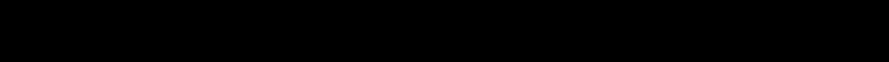
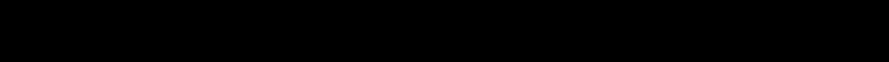
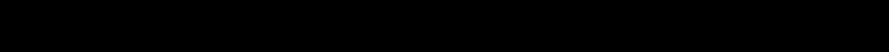
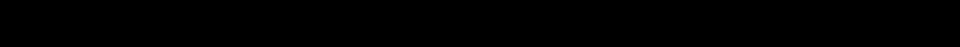
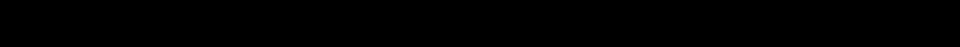
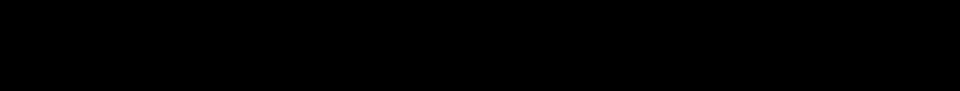

In [ ]:
import os
import copy
import time
import warnings
from typing import Literal
from itertools import combinations

import numpy as np
import pandas as pd
import arviz as az

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

import config as cnfg
from analysis.helpers.read_data import load_data
from pipeline.stage3_classify.build_funnels import build_event_classification_funnel

from _publications_._modeling import (
    AnalysisContext, ContrastGroupSelectorType, ContrastGroupType, ContrastType,
    load_cached_data, execute_pipeline, load_or_fit_model, _make_predictors_df,
)
from _publications_._plotting import (
    save_figure, finalize_figure, plot_posterior_distributions, get_annotation_text,
    add_posterior_bar_trace, add_posterior_scatter_trace, add_empirical_scatter_trace,
    add_statistical_annotations, LABEL_FONT, TICK_FONT,
)
from _publications_._assets import make_qr_png

start_time = time.time()
pio.renderers.default = "notebook"      # "notebook" or "browser"
warnings.filterwarnings("ignore", category=UserWarning, message=".*FigureCanvasAgg is non-interactive.*")

## Constants

In [ ]:
POSTER_SUBJECTS = [2, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

SEED = 42
RNG = np.random.default_rng(SEED)

### Paths

In [ ]:
EVENT_TYPE: Literal["fixation", "visit"] = "visit"

OUTPUT_PATH = os.path.join(cnfg.PUBLICATIONS_PATH, "2026_05_VSS")
os.makedirs(OUTPUT_PATH, exist_ok=True)

MODEL_DATA_PATH = os.path.join(OUTPUT_PATH, f"{EVENT_TYPE}_data.pkl")
IDATA_PATH = os.path.join(OUTPUT_PATH, f"{EVENT_TYPE}_idata.nc")
PREDS_PATH = os.path.join(OUTPUT_PATH, f"{EVENT_TYPE}_preds.nc")

## Model Data Preparation
We load the `MODEL_DATA`, `IDATA` and `PREDS` objects from disk if they exist.<br>
If any of these files are missing, we run the full pipeline to generate them. This pipeline includes:
1) Loading the raw funnel data and preparing it for modeling by filtering to the relevant rows and columns.
2) Building a new Bambi model using the specified formula and the prepared data.
3) Fitting the model to the data to obtain the inference data (`idata`).
4) Generating predictions from the fitted model (`preds`).
5) Saving the inference data and predictions to disk for future use.

### Helper Functions

### Load or Generate Data

In [ ]:
MODEL_DATA, IDATA, PREDS = load_or_fit_model(
    EVENT_TYPE, MODEL_DATA_PATH, IDATA_PATH, PREDS_PATH, subjects=POSTER_SUBJECTS, seed=SEED,
)

##### Sanity Check:

In [ ]:
assert isinstance(MODEL_DATA, pd.DataFrame), f"MODEL_DATA is not a DataFrame, but a {type(MODEL_DATA)}"
assert isinstance(IDATA, az.InferenceData), f"IDATA is not an InferenceData object, but a {type(IDATA)}"
assert isinstance(PREDS, az.InferenceData), f"PREDS is not an InferenceData object, but a {type(PREDS)}"

## Sampling & Convergence Diagnostics
Once `IDATA` is either loaded or generated, we check the sampling diagnostics to ensure that the model fitting process was successful and that the results are reliable.

#### (1) R-hat & ESS
We check the R-hat values for all parameters to ensure they are close to 1, which indicates good convergence between sampling chains.<br>
We also check the effective sample size (ESS) to ensure that we have enough (>400) independent samples for reliable inference within each chain (ESS_bulk) and in the tails of the distribution (ESS_tail).<br>

In [ ]:
idata_summary = az.summary(
    IDATA,
    var_names=[
        "Intercept",
        "trial_category", "target_category", "centered_abs_target_angle",
        "trial_category:target_category", "trial_category:centered_abs_target_angle", "target_category:centered_abs_target_angle",
        "trial_category:target_category:centered_abs_target_angle",
    ]
)

print(f"Number of R-hat above 1.01: {(idata_summary['r_hat'] > 1.01).sum()} / {idata_summary.shape[0]}")
print(f"Min ESS_bulk: {idata_summary['ess_bulk'].min():.1f}")
print(f"Min ESS_tail: {idata_summary['ess_tail'].min():.1f}")

#### (2) Divergence Count
We check the number of divergent transitions during sampling, as divergences can indicate issues with model convergence and may require reparameterization or adjustments to the sampling parameters (e.g., increasing `target_accept`).<br>
If the rate of divergence exceeds our predefined threshold (`rate_diverge > MAX_DIVERGENCE_RATE`), we also plot the pairwise relationships between parameters, highlighting the divergent transitions, to visually inspect for any problematic areas in the parameter space. We look for any patterns or clusters of divergences that may indicate issues with specific parameters or interactions.

In [ ]:
MAX_DIVERGENCE_RATE = 0.001

n_diverge = int(IDATA.sample_stats["diverging"].sum())
rate_diverge = IDATA.sample_stats["diverging"].data.mean()
print(f"Divergences Count:\t{n_diverge}")
print(f"Divergence Rate:\t{rate_diverge}")
if rate_diverge > MAX_DIVERGENCE_RATE:
    print("Divergences detected! Plotting pairwise relationships to inspect...")
    az.plot_pair(IDATA, divergences=True)

#### (3) Chain Mixing & Overlapping Convergance
We visually inspect the trace plots for each parameter to ensure that the chains are well-mixed and have converged to the same distribution. We look for stable, overlapping traces without trends or drifts

In [ ]:
axes = az.plot_trace(IDATA, var_names=["Intercept", "trial_category", "target_category", "centered_abs_target_angle"])
fig = axes.ravel()[0].figure
fig.set_size_inches(12, 14)
fig.subplots_adjust(hspace=0.6)  # more vertical space
fig.tight_layout()
fig.show()

#### (4) Energy
We check the energy plot to identify any potential issues with the sampling process.<br>
We look for **overlapping** energy distributions between initial energy ("Marginal Energy") and the energy after sampling step ("Energy Transition").<br>
The figure also shows the _Bayesian Fraction of Missing Information_ (BFMI) value for each chain, which indicates how well the sampler is exploring the energy landscape. A BFMI value close to 1 suggests good exploration, while values at 0.2 or below indicate poor exploration and a potential need for reparameterization or adjustments to the sampling parameters.

In [ ]:
ax = az.plot_energy(IDATA)
fig = ax.figure
fig.show()

## Statistical Analysis
We use the `idata` and `preds` objects to compare the probability of a LWS error across different conditions and contrasts.<br>
**Important Note:**<br>
While convergence diagnostics were performed on the `idata` object, statistical analyses and data visualizations will rely on the posterior distributions stored in the `preds` object (extracted using `preds["posterior"]["p"]`). This is because the empirical data is sparse, missing some combinations of the predictor levels (e.g., some subjects had no visits to `object natural` targets in the `noise` condition), which can lead to unreliable estimates of the effects for those conditions when relying solely on the posterior distributions of the model parameters (`idata["posterior"]`).<br>
To visualize the data, we will plot the posterior probabilities with their 95% credible intervals, and overlay the raw data points (from `MODEL_DATA`) to show the observed LWS probabilities for each condition.

In [ ]:
PREDICTORS = _make_predictors_df(MODEL_DATA)
POSTERIOR_PROBS = PREDS.posterior["p"]
CONTEXT = AnalysisContext(model_data=MODEL_DATA, predictors=PREDICTORS, posterior_probs=POSTERIOR_PROBS)

### Overall Error Rates
Before diving into the specific contrasts, we first examine the overall error rates across subjects to get a general sense of the data and the model's predictions.<br>
We calculate the empirical mean LWS probability for each subject from the `MODEL_DATA`, and then calculate the mean and standard error of the mean (SEM) across subjects to get an overall estimate of the empirical error rate.

In [ ]:
EMPIRICAL_SUBJECT_MEANS = MODEL_DATA.groupby("subject", observed=True)["is_lws"].mean()
print(f"Empirical Error Rate:\t{100 * EMPIRICAL_SUBJECT_MEANS.mean() :.2f}% ± {100 * EMPIRICAL_SUBJECT_MEANS.sem():.2f}\t(mean ± SEM across subjects)")

POSTERIOR_SUBJECT_MEANS = {}
for subj in EMPIRICAL_SUBJECT_MEANS.index:
    subj_idxs = np.where(PREDICTORS["subject"] == subj)[0]
    subj_mean = POSTERIOR_PROBS.isel(__obs__=subj_idxs).mean(dim="__obs__").mean().item()
    POSTERIOR_SUBJECT_MEANS[subj] = subj_mean
POSTERIOR_SUBJECT_MEANS = pd.Series(POSTERIOR_SUBJECT_MEANS)
del subj, subj_idxs, subj_mean
print(f"Posterior Error Rate:\t{100 * POSTERIOR_SUBJECT_MEANS.mean() :.2f}% ± {100 * POSTERIOR_SUBJECT_MEANS.sem():.2f}\t(mean ± SEM across subjects)")

### (1) Semantic Contrasts

In [ ]:
az.summary(PREDS, var_names=["Intercept", "target_category"])

#### Animacy Effect: Animate vs. Inanimate

In [ ]:
animacy_contrast = ContrastType(
    name="Animate vs. Inanimate",
    group1=ContrastGroupType(
        name="Animate",
        selectors=(
            ContrastGroupSelectorType("target_category", ("ANIMAL_OTHER", "HUMAN_OTHER", "ANIMAL_FACE", "HUMAN_FACE")),
        )
    ),
    group2=ContrastGroupType(
        name="Inanimate",
        selectors=(
            ContrastGroupSelectorType("target_category", ("OBJECT_HANDMADE", "OBJECT_NATURAL")),
        )
    ),
)

animacy_results = animacy_contrast.calculate_contrast(CONTEXT, verbose=True)
animacy_contrast.plot_posteriors(CONTEXT)

#### Human Face Effect: Human Faces vs. Other Animates

In [ ]:
human_face_contrast = ContrastType(
    name="Human Face vs. Other Animate",
    group1=ContrastGroupType(
        name="Human Face",
        selectors=(
            ContrastGroupSelectorType("target_category", ("HUMAN_FACE",)),
        )
    ),
    group2=ContrastGroupType(
        name="Other Animate",
        selectors=(
            ContrastGroupSelectorType("target_category", ("ANIMAL_OTHER", "HUMAN_OTHER", "ANIMAL_FACE")),
        )
    ),
)

human_face_results = human_face_contrast.calculate_contrast(CONTEXT, verbose=True)
human_face_contrast.plot_posteriors(CONTEXT)

#### Natural vs Hand-Made Contrast

In [ ]:
objects_contrast = ContrastType(
    name="Hand-Made vs. Natural",
    group1=ContrastGroupType(
        name="Hand-Made",
        selectors=(
            ContrastGroupSelectorType("target_category", ("OBJECT_HANDMADE",)),
        )
    ),
    group2=ContrastGroupType(
        name="Natural",
        selectors=(
            ContrastGroupSelectorType("target_category", ("OBJECT_NATURAL",)),
        )
    ),
)

objects_contrast_result = objects_contrast.calculate_contrast(CONTEXT, verbose=True)
objects_contrast.plot_posteriors(CONTEXT)

#### Semantic Contrasts Visualization

In [ ]:
contrast_positions = {animacy_contrast: (0.0, 0.8), human_face_contrast: (1.8, 2.6), objects_contrast: (3.6, 4.4)}
semantic_contrasts_fig = go.Figure()

x_ticks = {}            # position -> group name
stat_annotations = []   # text & position of annotations
highest_y = 0           # height of "tallest bar"
for i, contrast in enumerate(contrast_positions.keys()):
    contrast_p = contrast.calculate_positive_contrast_probability(CONTEXT)
    ann_text = get_annotation_text(contrast_p)
    stat_annotations.append((ann_text, *contrast_positions[contrast]))
    for j, grp in enumerate([contrast.group1, contrast.group2]):
        xpos = contrast_positions[contrast][j]
        bar_height = add_posterior_bar_trace(
            semantic_contrasts_fig, grp, CONTEXT, xpos,
            color=cnfg.get_discrete_color(i),
            pattern="" if j == 0 else "/"
        )
        scatter_height = add_empirical_scatter_trace(
            semantic_contrasts_fig, grp, CONTEXT, xpos, rng=RNG,
        )
        # update coordinate
        x_ticks[xpos] = grp.name
        highest_y = max(highest_y, bar_height, scatter_height)

# add statistical annotations with underlying line
annotation_y = int(100 * highest_y) / 100 + 0.025       # round up to the nearest 0.025 for better annotation placement
add_statistical_annotations(semantic_contrasts_fig, stat_annotations, y_pos=annotation_y)

# update graphics
finalize_figure(
    semantic_contrasts_fig,
    title="Target Category Contrasts",
    x_label="Target Category", x_tickvals=list(x_ticks.keys()), x_ticklabels=list(x_ticks.values()),
)
semantic_contrasts_fig.update_yaxes(
    tickmode="array", tickvals=np.arange(0, 0.6, 0.1), ticktext=[f"{r:.1f}" for r in np.arange(0, 0.6, 0.1)],
)
for xline in [1.3, 3.1]:
    semantic_contrasts_fig.add_shape(
        type="line", x0=xline, x1=xline,
        y0=0.01, y1=highest_y*0.95,
        line=dict(dash="dot", width=3, color="black")
    )

# save_figure(semantic_contrasts_fig, "semantic_contrasts", 44.5, 26.2, output_dir=OUTPUT_PATH, dpi=300)
semantic_contrasts_fig.show()

### (2) Trial Type Effect

In [ ]:
az.summary(PREDS, var_names=["Intercept", "trial_category"])

In [ ]:
trial_type_groups = [
    ContrastGroupType(
        name="Color", selectors=(ContrastGroupSelectorType("trial_category", ("COLOR",)),)
    ),
    ContrastGroupType(
        name="Grayscale", selectors=(ContrastGroupSelectorType("trial_category", ("BW",)),)
    ),
    ContrastGroupType(
        name="Noise BG", selectors=(ContrastGroupSelectorType("trial_category", ("NOISE",)),)
    ),
]
for (g1, g2) in combinations(trial_type_groups, 2):
    contrast_result = ContrastType(name="", group1=g1, group2=g2).calculate_contrast(CONTEXT, verbose=True)
    print("-----------------------------")

plot_posterior_distributions(trial_type_groups, CONTEXT, title="Posterior Distributions: Trial Type Effect")

In [ ]:
trial_type_fig = go.Figure()

bar_top = 0             # tallest posterior bar (mean + SEM), used to place the annotation stack
max_subject_mean = 0    # tallest raw per-subject dot, must stay fully visible on the y-axis
for i, grp in enumerate(trial_type_groups):
    bar_height = add_posterior_bar_trace(
        trial_type_fig, grp, CONTEXT, i,
        color=cnfg.get_discrete_color(i),
        pattern=""
    )
    add_empirical_scatter_trace(
        trial_type_fig, grp, CONTEXT, i, rng=RNG,
    )
    bar_top = max(bar_top, bar_height)
    max_subject_mean = max(max_subject_mean, grp.extract_empirical_probabilities_per_subject(CONTEXT)["mean"].max())

# two annotation tiers: adjacent-pair brackets low, the pair spanning all three groups above them
short_annotations, long_annotations = [], []
for (g1, g2) in combinations(trial_type_groups, 2):
    x1 = trial_type_groups.index(g1)
    x2 = trial_type_groups.index(g2)
    contrast_p = ContrastType(name="", group1=g1, group2=g2).calculate_positive_contrast_probability(CONTEXT)
    ann_text = get_annotation_text(contrast_p)
    entry = (ann_text, x1 + 0.1, x2 - 0.1)
    (long_annotations if x2 - x1 > 1 else short_annotations).append(entry)

annotation_y_short = bar_top + 0.17
annotation_y_long = annotation_y_short + 0.08
add_statistical_annotations(trial_type_fig, short_annotations, y_pos=annotation_y_short)
add_statistical_annotations(trial_type_fig, long_annotations, y_pos=annotation_y_long)

# y-axis extends just far enough to fit the annotations and the tallest subject mean (its own
# error bar may get clipped); the last labeled gridline stays one 0.1-step below that true top,
# so a mostly-empty top step doesn't get its own "0.7"-style label.
y_axis_max = max(max_subject_mean + 0.01, annotation_y_long + 0.03)
tick_max = np.floor(y_axis_max * 10) / 10

# update graphics
finalize_figure(
    trial_type_fig,
    title="Trial Type Effect",
    x_label="Trial Type",
    x_tickvals=list(range(len(trial_type_groups))),
    x_ticklabels=[t.name for t in trial_type_groups],
)
trial_type_fig.update_yaxes(
    range=[0, y_axis_max],
    tickmode="array", tickvals=np.arange(0, tick_max + 1e-9, 0.1), ticktext=[f"{r:.1f}" for r in np.arange(0, tick_max + 1e-9, 0.1)],
)

# save_figure(trial_type_fig, "trial_type", 44.5, 25.2, output_dir=OUTPUT_PATH, dpi=300)
trial_type_fig.show()

### (3) Target Angle Effect

In [ ]:
az.summary(PREDS, var_names=["Intercept", "centered_abs_target_angle", "trial_category:centered_abs_target_angle"])

In [ ]:
MEAN_ABS_ANGLE = MODEL_DATA["abs_target_angle"].mean()

In [ ]:
angle_groups = sorted(
    [ContrastGroupType(
        name=f"{int(deg + MEAN_ABS_ANGLE)}°", selectors=(ContrastGroupSelectorType("centered_abs_target_angle", (deg,)),)
    ) for deg in MODEL_DATA["centered_abs_target_angle"].unique()],
    key=lambda grp: int(grp.name.split("°")[0])
)

angle_contrast_groups = [angle_groups[0], angle_groups[-1]]     # contrast 0° and 20°
angle_contrast = ContrastType(name="", group1=angle_contrast_groups[0], group2=angle_contrast_groups[1])
angle_contrast.calculate_contrast(CONTEXT, verbose=True)
plot_posterior_distributions(
    [grp for grp in angle_groups if grp.name in ["0°", "10°", "20°"]],
    CONTEXT,
    title="Posterior Distributions: Target Angle Effect"
)

In [ ]:
target_angle_contrast_fig = go.Figure()
highest_y = 0
for i, grp in enumerate(angle_contrast_groups):
    bar_height = add_posterior_bar_trace(
        target_angle_contrast_fig, grp, CONTEXT, i,
        color=cnfg.get_discrete_color(i),
        pattern=""
    )
    scatter_height = add_empirical_scatter_trace(
        target_angle_contrast_fig, grp, CONTEXT, i, rng=RNG,
    )
    highest_y = max(highest_y, bar_height, scatter_height)

stat_annotations = []
for (g1, g2) in combinations(angle_contrast_groups, 2):
    x1 = angle_contrast_groups.index(g1)
    x2 = angle_contrast_groups.index(g2)
    contrast_p = ContrastType(name="", group1=g1, group2=g2).calculate_positive_contrast_probability(CONTEXT)
    ann_text = get_annotation_text(contrast_p)
    stat_annotations.append((ann_text, x1+0.1, x2-0.1))

# add statistical annotations with underlying line
annotation_y = int(100 * highest_y) / 100 + 0.025       # round up to the nearest 0.025 for better annotation placement
add_statistical_annotations(target_angle_contrast_fig, stat_annotations, y_pos=annotation_y)

# update graphics
finalize_figure(
    target_angle_contrast_fig,
    title="Target Angle Effect",
    x_label="Target Angle",
    x_tickvals=list(range(len(angle_contrast_groups))),
    x_ticklabels=[t.name for t in angle_contrast_groups],
)
target_angle_contrast_fig.update_layout(width=1000, height=500)

target_angle_contrast_fig.show()

In [ ]:
target_angle_fig = make_subplots(
    rows=1, cols=2, column_widths=[0.7, 0.3],
    shared_yaxes=True, horizontal_spacing=0.025,
)

# populate the right subplot (0°-20° contrast)
for tr in target_angle_contrast_fig.data:
    if tr.type == "bar":
        target_angle_fig.add_trace(trace=tr, row=1, col=2)
for shp in target_angle_contrast_fig.layout.shapes or []:
    new_shape = copy.deepcopy(shp)
    new_shape.y0 = new_shape.y1 = 0.31
    new_shape.x0 -= 0.25
    new_shape.x1 += 0.25
    target_angle_fig.add_shape(new_shape, row=1, col=2)
for ann in target_angle_contrast_fig.layout.annotations or []:
    new_ann = copy.deepcopy(ann)
    ann.y = 0.31
    target_angle_fig.add_annotation(ann, row=1, col=2)

# populate the left subplot (bar per angle)
for i, grp in enumerate(angle_groups):
    scatter_height = add_posterior_scatter_trace(
        target_angle_fig, grp, CONTEXT, i,
        color=cnfg.get_discrete_color("all"),
        symbol="circle",
        size=8
    )
    highest_y = max(highest_y, scatter_height)

# update graphics
target_angle_fig.update_xaxes(
    title=dict(text="Target Angle", font=LABEL_FONT, standoff=10),
    tickfont=TICK_FONT,
    showgrid=False,
)
target_angle_fig.update_xaxes(
    row=1, col=1,
    tickmode="array",
    tickvals=list(range(0, len(angle_groups)+1, 5)),
    ticktext=[angle_groups[i].name for i in range(0, len(angle_groups)+1, 5)],

)
target_angle_fig.update_xaxes(
    row=1, col=2,
    tickmode="array",
    tickvals=list(range(len(angle_contrast_groups))),
    ticktext=[t.name for t in angle_contrast_groups],
)

target_angle_fig.update_yaxes(
    showgrid=True, gridcolor=cnfg.GRID_LINE_COLOR, gridwidth=cnfg.GRID_LINE_WIDTH,
    zeroline=True, zerolinecolor="black", zerolinewidth=2,
    range=[-0.05, 0.35],
    tickfont=TICK_FONT,
    tickmode="array", tickvals=np.arange(0, 0.4, 0.1), ticktext=[f"{r:.1f}" for r in np.arange(0, 0.4, 0.1)],
)
target_angle_fig.update_yaxes(
    row=1, col=1,
    title=dict(text="P[recog. error | target visit]", font=LABEL_FONT, standoff=10),
)

target_angle_fig.update_layout(
    title=dict(
        text="Target Angle Effect", font=cnfg.TITLE_FONT,
        x=0.5, xanchor="center", y=0.95, yanchor="middle",
    ),
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=40, r=15, t=60, b=20),
)

# save_figure(target_angle_fig, "target_angle", 44.5, 26.2, output_dir=OUTPUT_PATH, dpi=300)
target_angle_fig.show()

#### Target Angle in Grayscale Trials

In [ ]:
grayscale_group = ContrastGroupType(name="grayscale", selectors=(ContrastGroupSelectorType("trial_category", ("BW",)),))
grayscale_angle_groups = [ContrastGroupType.intersect_groups([angle_grp, grayscale_group]) for angle_grp in angle_groups]
del grayscale_group

grayscale_angle_contrast = ContrastType(name="", group1=grayscale_angle_groups[0], group2=grayscale_angle_groups[-1])
grayscale_angle_contrast.calculate_contrast(CONTEXT, verbose=True)
plot_posterior_distributions(
    [grp for grp in grayscale_angle_groups if grp.name in ["0° ∩ grayscale", "10° ∩ grayscale", "20° ∩ grayscale"]],
    CONTEXT,
    title="Posterior Distributions: Target Angle Effect [Grayscale Trials]"
)

## Data Funnel
We include a small funnel chart depicting the number/percent of _target visits_ that were analyzed and of those how many were considered a **LWS** instance.

In [ ]:
initial_step = f"<b>Target {EVENT_TYPE.capitalize()}</b>"
_funnel_data = load_data(cnfg.OUTPUT_PATH)
_funnel_valid = _funnel_data.trial_funnel.loc[_funnel_data.trial_funnel["is_valid_trial"], ["subject", "trial"]]
funnel_sizes = (
    build_event_classification_funnel(_funnel_data, "lws", EVENT_TYPE)
    .merge(_funnel_valid, on=["subject", "trial"], how="inner")
    .query("subject in @POSTER_SUBJECTS")
    .loc[:, [
        "subject", "upto_on_target", "upto_before_identification", "upto_not_close_to_trial_end", "upto_not_before_exemplar_visit", "is_lws"
    ]]
    .rename(columns={
        "upto_on_target": initial_step,
        "upto_before_identification":     "                                                    " +
                                     "↳ Exclude post-identification",
        "upto_not_close_to_trial_end":    "                                                    " +
                                     "                " + "↳ Exclude <1s from trial end",
        "upto_not_before_exemplar_visit": "                                                    " +
                                     "                " + "                " + "↳ Exclude if precedes<br>" +
                                     "                                                    " +
                                     "                " + "                " + "    " + "target-exemplar fixation",
        "is_lws": "<b>Recognition Error</b>"
    })
    .groupby(["subject"], observed=True)
    .sum()
    .agg(["median", "mean", "sem"])
    .T
    .assign(ratio=lambda df: df["mean"] / df.loc[initial_step, "mean"])
)
del _funnel_data, _funnel_valid

# build figure
funnel_fig = go.Figure()
funnel_fig.add_trace(go.Bar(
    y=funnel_sizes.index,
    x=funnel_sizes["mean"],
    orientation='h',
    error_x=dict(
        type='data',
        array=funnel_sizes["sem"],
        color="rgba(0,0,0,1.0)",
        thickness=2,
        width=8,
        visible=True
    ),
    marker=dict(color=["gray", "lightgray", "lightgray", "lightgray", "gray"]),
    text=[f"{row['mean']:.1f}±{row['sem']:.1f} ({100 * row['ratio']:.1f}%)" for _, row in funnel_sizes.iterrows()],
    textposition='inside', insidetextanchor='start', textfont={**cnfg.SUBTITLE_FONT, **{"size": 32}},
    hoverinfo="y+x"
))

# update graphics
xmax = (funnel_sizes["mean"] + funnel_sizes["sem"]).max()
funnel_fig.update_xaxes(
    title=dict(text=f"{EVENT_TYPE.capitalize()} Count", font=cnfg.AXIS_LABEL_FONT, standoff=10),
    tickfont=cnfg.AXIS_TICK_FONT,
    showgrid=False, gridcolor=cnfg.GRID_LINE_COLOR, gridwidth=cnfg.GRID_LINE_WIDTH,
    zeroline=True, zerolinecolor=cnfg.GRID_LINE_COLOR, zerolinewidth=cnfg.GRID_LINE_WIDTH,
    # autorange="reversed",       # puts 0 on right side
    range=[xmax * 1.225, 0],      # puts 0 on the right side and lets y-axis labels "overflow" onto the plot
    visible=False,
)
funnel_fig.update_yaxes(
    tickfont={**cnfg.SUBTITLE_FONT, **{"size": 40}}, ticklabelposition="inside",
    showgrid=False, gridcolor=cnfg.GRID_LINE_COLOR, gridwidth=cnfg.GRID_LINE_WIDTH,
    zeroline=False, zerolinecolor=cnfg.GRID_LINE_COLOR, zerolinewidth=cnfg.GRID_LINE_WIDTH,
    autorange="reversed",       # puts the first step at the top
)
funnel_fig.update_layout(
    title=dict(
        text=f"Error Classification Funnel", font=cnfg.TITLE_FONT,
        x=0.5, xanchor="center", y=0.95, yanchor="middle",
    ),
    template="plotly_white",
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=10, r=10, t=50, b=5),
)

# save_figure(funnel_fig, "funnel", 45.2, 16.25, output_dir=OUTPUT_PATH, dpi=300)
funnel_fig.show()

## QR Code
The poster also includes three (3) QR codes that lead to the following resources:
- this notebook (stored on GitHub)
- a video of a single trial from the experiment, including eye movement data (stored on YouTube)
- a short preprint on the benefits of sharing data in visual search research (stored on PsyArXiv)

In [ ]:
NOTEBOOK_URL = r"https://github.com/JonNir1/LWSv1/blob/main/_publications_/2026_vss.ipynb"
VIDEO_URL = r"https://youtu.be/AA8_5NtFtEU"
SHARING_PREPRINT_URL = r"https://osf.io/preprints/psyarxiv/q8jrd"
URL_MAP = {"analysis": NOTEBOOK_URL, "video": VIDEO_URL, "preprint": SHARING_PREPRINT_URL}

In [ ]:
analysis_qr = make_qr_png("analysis", OUTPUT_PATH, URL_MAP)
video_qr = make_qr_png("video", OUTPUT_PATH, URL_MAP)
preprint_qr = make_qr_png("preprint", OUTPUT_PATH, URL_MAP)

## Misc.

In [ ]:
elapsed = time.time() - start_time
print(f"Total runtime:\t{elapsed:.2f} seconds")